# 02 EDA

## 1. Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent

Q8_PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_q8_processed_only.csv"
HEALTH_RISK_PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_health_risk_processed_only.csv"

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# Load processed-only data
# ------------------------------------------------------------
analysis = pd.read_csv(Q8_PROCESSED_PATH)
health_risk = pd.read_csv(HEALTH_RISK_PROCESSED_PATH)

print("Rows valid for Q8 analysis:", len(analysis))

Rows valid for Q8 analysis: 13174


## 2. Visualization 1: Current Cigarette Use Proportion by Group

### 2.1 Group Summary

The main response variable is binary, so the key descriptive statistic is the current cigarette use proportion in each Sad/Hopeless group.

- `sad_binary = 1`: Sad/Hopeless: Yes
- `sad_binary = 0`: Sad/Hopeless: No
- `smoker_binary = 1`: Current smoker
- `smoker_binary = 0`: Non-smoker


In [2]:
summary = (
    analysis
    .groupby(["sad_binary", "sad_group"], as_index=False)
    .agg(
        n=("smoker_binary", "count"),
        current_cigarette_users=("smoker_binary", "sum"),
        current_cigarette_proportion=("smoker_binary", "mean")
    )
)

summary["current_cigarette_percent"] = summary["current_cigarette_proportion"] * 100
summary = summary.sort_values("sad_binary", ascending=False).reset_index(drop=True)

summary.to_csv(TAB_DIR / "02_group_summary.csv", index=False)
display(summary)

,sad_binary,sad_group,n,current_cigarette_users,current_cigarette_proportion,current_cigarette_percent
0,1,Sad/Hopeless: Yes,3854,1064,0.2761,27.6077
1,0,Sad/Hopeless: No,9320,1508,0.1618,16.1803


### 2.2 EDA

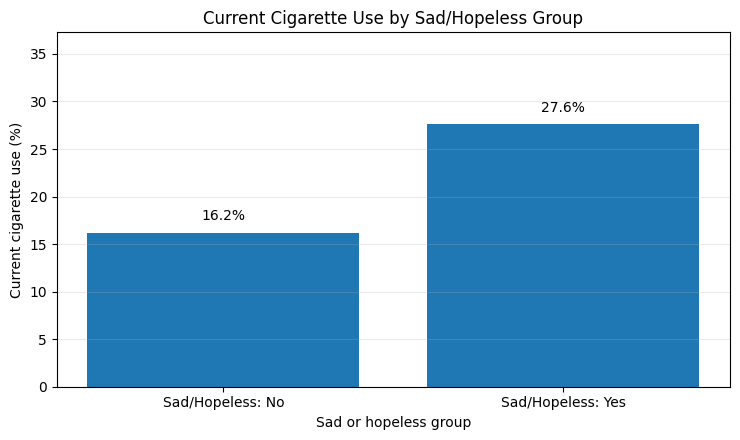

In [3]:
plot_summary = summary.copy()
plot_summary["sad_group"] = pd.Categorical(
    plot_summary["sad_group"],
    categories=["Sad/Hopeless: No", "Sad/Hopeless: Yes"],
    ordered=True
)
plot_summary = plot_summary.sort_values("sad_group")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(plot_summary["sad_group"].astype(str), plot_summary["current_cigarette_percent"])

ax.set_ylabel("Current cigarette use (%)")
ax.set_xlabel("Sad or hopeless group")
ax.set_title("Current Cigarette Use by Sad/Hopeless Group")
ax.set_ylim(0, plot_summary["current_cigarette_percent"].max() * 1.35)

for bar, val in zip(bars, plot_summary["current_cigarette_percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(FIG_DIR / "02_current_cigarette_use_by_sad_group_bar.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Interpretation**

This bar chart compares the current cigarette use proportion between the **Sad/Hopeless: Yes** group and the **Sad/Hopeless: No** group.

The **Sad/Hopeless: Yes** group had a higher current cigarette use proportion than the **Sad/Hopeless: No** group. This suggests that students who felt sad or hopeless were more likely to report current cigarette use in the sample.

## 3. Visualization 2: Smoking Frequency Composition by Group

### 3.1 Smoking Frequency Groups
- Light (1~5 days)
- Moderate (6~19 days)
- Frequent (20~30 days)

In [4]:
# ------------------------------------------------------------
# Smoking frequency group table among current smokers only
# ------------------------------------------------------------

freq_order = [
    "Light (1~5 days)",
    "Moderate (6~19 days)",
    "Frequent (20~30 days)",
]

group_order = ["Sad/Hopeless: No", "Sad/Hopeless: Yes"]

# Keep only current smokers
smoker_only = analysis[
    (analysis["smoker_binary"] == 1) &
    (analysis["smoking_freq_group"].isin(freq_order))
].copy()

# Count table
freq_counts = (
    pd.crosstab(
        smoker_only["sad_group"],
        smoker_only["smoking_freq_group"]
    )
    .reindex(index=group_order, columns=freq_order, fill_value=0)
    .fillna(0)
    .astype(int)
)

# Percentage table
# Denominator = current smokers within each Sad/Hopeless group
freq_props = (
    pd.crosstab(
        smoker_only["sad_group"],
        smoker_only["smoking_freq_group"],
        normalize="index"
    )
    .reindex(index=group_order, columns=freq_order, fill_value=0)
    .fillna(0) * 100
)

freq_table = (
    freq_counts
    .reset_index()
    .melt(
        id_vars="sad_group",
        var_name="smoking_freq_group",
        value_name="count"
    )
)

props_long = (
    freq_props
    .reset_index()
    .melt(
        id_vars="sad_group",
        var_name="smoking_freq_group",
        value_name="within_smoker_percent"
    )
)

freq_table = freq_table.merge(
    props_long,
    on=["sad_group", "smoking_freq_group"]
)

freq_table["within_smoker_percent"] = freq_table["within_smoker_percent"].round(1)

freq_table.to_csv(
    TAB_DIR / "02_smoking_freq_group_by_sad_group_smokers_only.csv",
    index=False
)

display(freq_table)

,sad_group,smoking_freq_group,count,within_smoker_percent
0,Sad/Hopeless: No,Light (1~5 days),687,45.6000
1,Sad/Hopeless: Yes,Light (1~5 days),437,41.1000
2,Sad/Hopeless: No,Moderate (6~19 days),307,20.4000
3,Sad/Hopeless: Yes,Moderate (6~19 days),231,21.7000
4,Sad/Hopeless: No,Frequent (20~30 days),514,34.1000
5,Sad/Hopeless: Yes,Frequent (20~30 days),396,37.2000


### 3.2 EDA

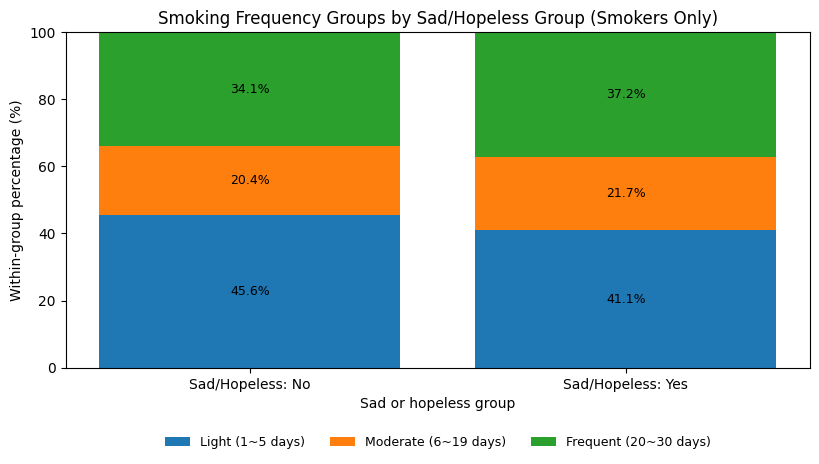

In [5]:
# Only keep current smokers for this visualization
smoker_only = analysis[
    (analysis["smoker_binary"] == 1) &
    (analysis["smoking_freq_group"].isin([
        "Light (1~5 days)",
        "Moderate (6~19 days)",
        "Frequent (20~30 days)"
    ]))
].copy()

# Crosstab: within each Sad/Hopeless group, among smokers only
freq_ct = pd.crosstab(
    smoker_only["sad_group"],
    smoker_only["smoking_freq_group"]
)

freq_props = pd.crosstab(
    smoker_only["sad_group"],
    smoker_only["smoking_freq_group"],
    normalize="index"
) * 100

# Save table if you want
freq_table = freq_ct.copy()
for col in freq_props.columns:
    freq_table[f"{col} (%)"] = freq_props[col].round(1)

freq_table.to_csv(TAB_DIR / "02_smoking_freq_group_by_sad_group_smokers_only.csv")

# Plot
group_order = ["Sad/Hopeless: No", "Sad/Hopeless: Yes"]
freq_order = [
    "Light (1~5 days)",
    "Moderate (6~19 days)",
    "Frequent (20~30 days)"
]

ct = freq_props.loc[group_order, freq_order]

fig, ax = plt.subplots(figsize=(8.3, 4.8))
bottom = [0] * len(ct)

for col in freq_order:
    vals = ct[col].values
    ax.bar(ct.index, vals, bottom=bottom, label=col)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_ylabel("Within-group percentage (%)")
ax.set_xlabel("Sad or hopeless group")
ax.set_title("Smoking Frequency Groups by Sad/Hopeless Group (Smokers Only)")
ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3, frameon=False, fontsize=9)

for i, row in enumerate(ct.values):
    running = 0
    for val in row:
        if val >= 6:
            ax.text(i, running + val / 2, f"{val:.1f}%", ha="center", va="center", fontsize=9)
        running += val

plt.tight_layout()
fig.savefig(FIG_DIR / "02_smoking_freq_group_stacked_by_sad_group_smokers_only.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Interpretation**

This stacked bar chart focuses only on students who were current cigarette users. It compares the smoking frequency composition between the **Sad/Hopeless: Yes** and **Sad/Hopeless: No** groups.

Among current smokers, the **Sad/Hopeless: Yes** group had a slightly higher share of **Frequent (20~30 days)** smokers than the **Sad/Hopeless: No** group.